# Chargement des librairies et données

In [87]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [88]:
# Charger l'ensemble de données billets
df_billets = pd.read_csv("billets.csv", sep=";")
df_billets.head()

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


# Préparation et nettoyage des données

In [89]:
df_billets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [90]:
df_billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


In [91]:
# Compter le nombre de vrais (True) et de faux (False)
print(df_billets['is_genuine'].value_counts())

is_genuine
True     1000
False     500
Name: count, dtype: int64


In [92]:
df_billets.groupby('is_genuine').mean()

,diagonal,height_left,height_right,margin_low,margin_up,length
is_genuine,,,,,,
False,171.90116,104.19034,104.14362,5.215935,3.35016,111.63064
True,171.98708,103.94913,103.80865,4.116097,3.05213,113.20243


## Répartition des dimensions

/Users/macherie/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1000x600 with 0 Axes>

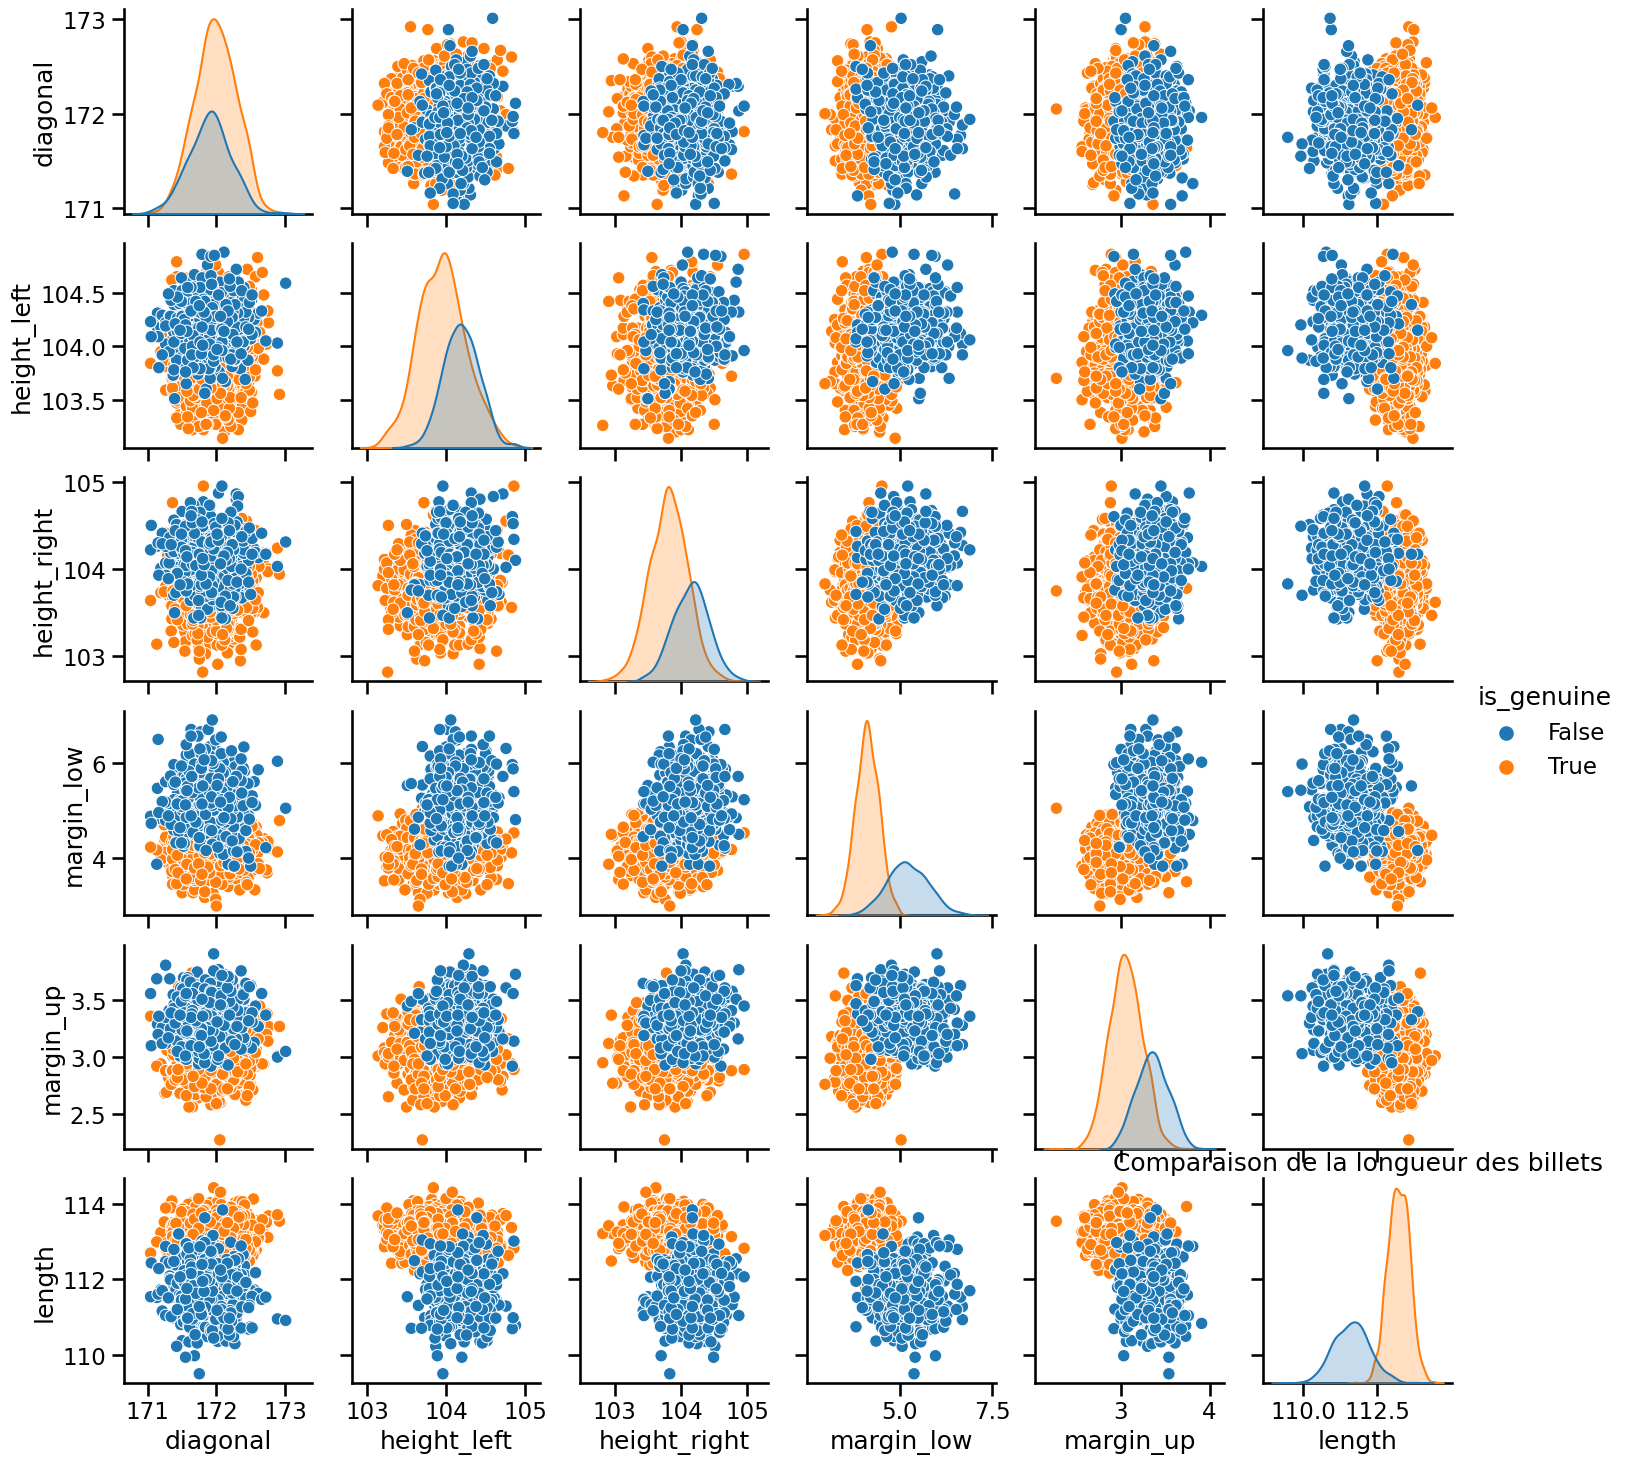

In [93]:
# Comparaison visuelle de la longueur entre vrais et faux Billets
plt.figure(figsize=(10,6))
sns.pairplot(df_billets, hue="is_genuine")
plt.title('Comparaison de la longueur des billets')
plt.savefig('comparaison_billets.png', dpi=300, bbox_inches='tight')
plt.show()


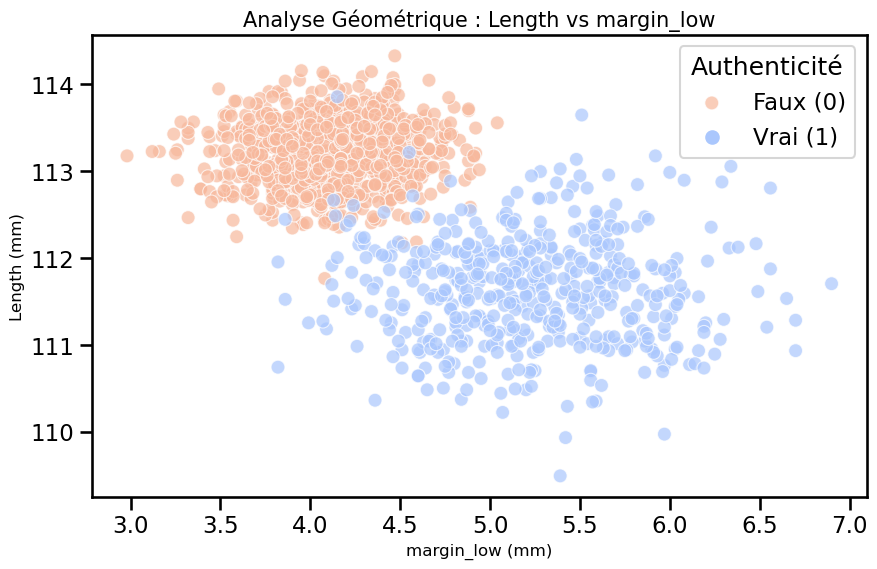

In [94]:
# 1. Configuration de la taille
plt.figure(figsize=(10, 6))

# 2. Création du scatterplot
# On croise 'length' et 'margin_low' avec une couleur par authenticité
ax = sns.scatterplot(data=df_billets, 
                     x='margin_low', 
                     y='length', 
                     hue='is_genuine', 
                     palette='coolwarm', 
                     alpha=0.7, 
                     s=100) # s=100 pour que les points soient bien visibles

# 3. Personnalisation des axes et du titre
plt.title('Analyse Géométrique : Length vs margin_low', fontsize=15)
plt.xlabel('margin_low (mm)', fontsize=12)
plt.ylabel('Length (mm)', fontsize=12)


# Amélioration de la légende
plt.legend(title='Authenticité', labels=['Faux (0)', 'Vrai (1)'])

# 4. Enregistrement de l'image
plt.savefig('scatter_length_margin.png', dpi=300, bbox_inches='tight')

# 5. Affichage
plt.show()

## Visualisation des valeurs manquantes

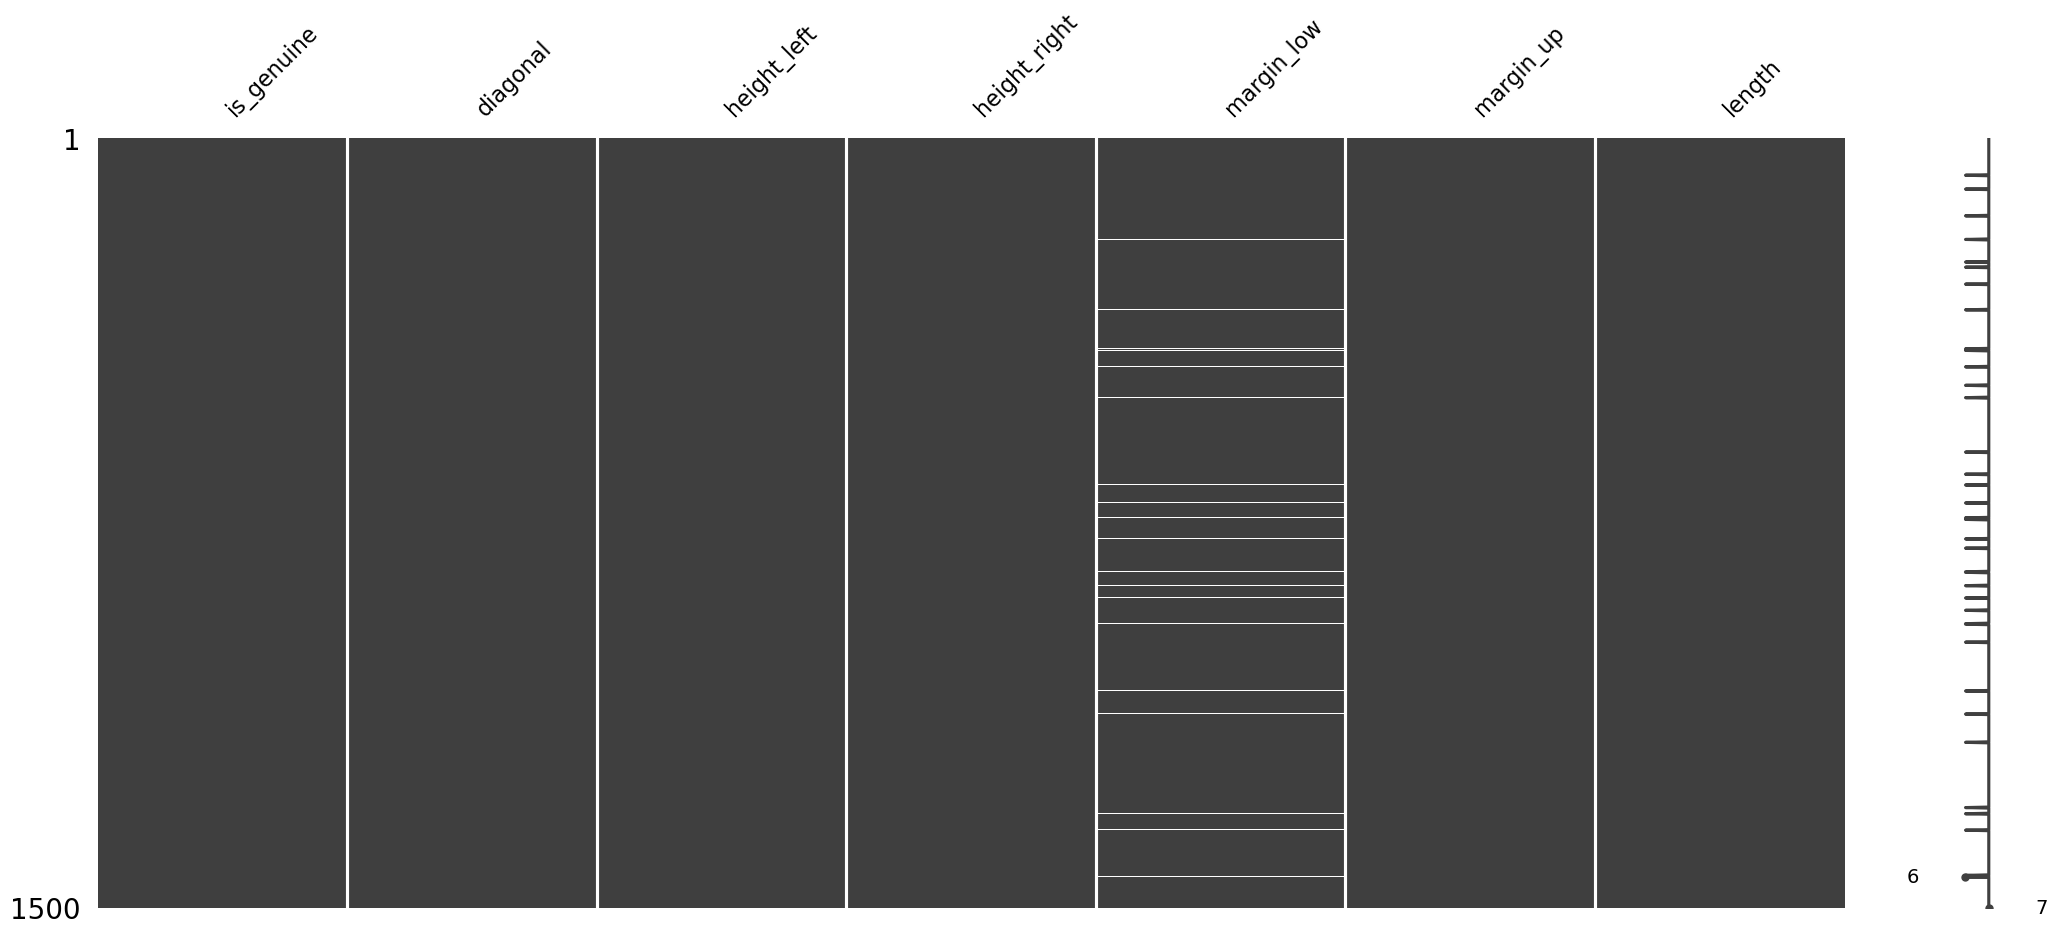

In [95]:
# Visualisation des valeurs manquantes
msno.matrix(df_billets)
plt.show()

In [96]:
# Tableau des valeurs manquantes par colonne
missing_values = df_billets.isnull().sum()
missing_percent = (missing_values / len(df_billets)) * 100
missing_table = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
print(missing_table)

              Missing Values  Percentage
is_genuine                 0    0.000000
diagonal                   0    0.000000
height_left                0    0.000000
height_right               0    0.000000
margin_low                37    2.466667
margin_up                  0    0.000000
length                     0    0.000000


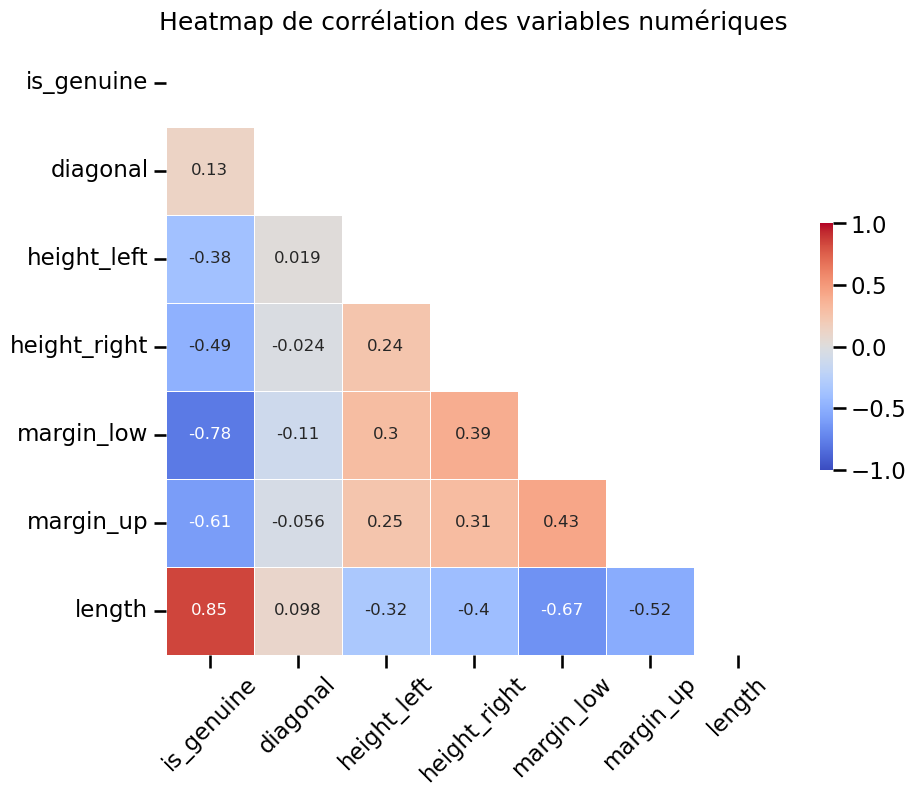

In [97]:

# 1. Calcul de la corrélation
corr_matrix = df_billets.corr()

# 2. Créer un masque pour cacher la partie supérieure (le triangle haut)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Création de la figure
fig, ax = plt.subplots(figsize=(10, 8))

# 4. Génération de la heatmap
sns.heatmap(corr_matrix,
            mask = mask,         
            square = True,
            linewidths = .5,
            cmap = 'coolwarm',
            cbar_kws = {'shrink': .4, 'ticks' : [-1, -.5, 0, 0.5, 1]},
            vmin = -1,
            vmax = 1,
            annot = True,
            annot_kws = {"size": 12},
            ax = ax)

# 5. Réglages des labels
ax.set_yticklabels(corr_matrix.columns, rotation = 0)
ax.set_xticklabels(corr_matrix.columns, rotation = 45)

plt.title('Heatmap de corrélation des variables numériques')
# Enregistre l'image en PNG avec une haute résolution (300 dpi)
plt.savefig("heatmap_oncfm.png", dpi=300, bbox_inches='tight')

plt.show()

/var/folders/px/vxsbq6f172sbrm6n__kccm1h0000gp/T/ipykernel_894/1983905477.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_billets,


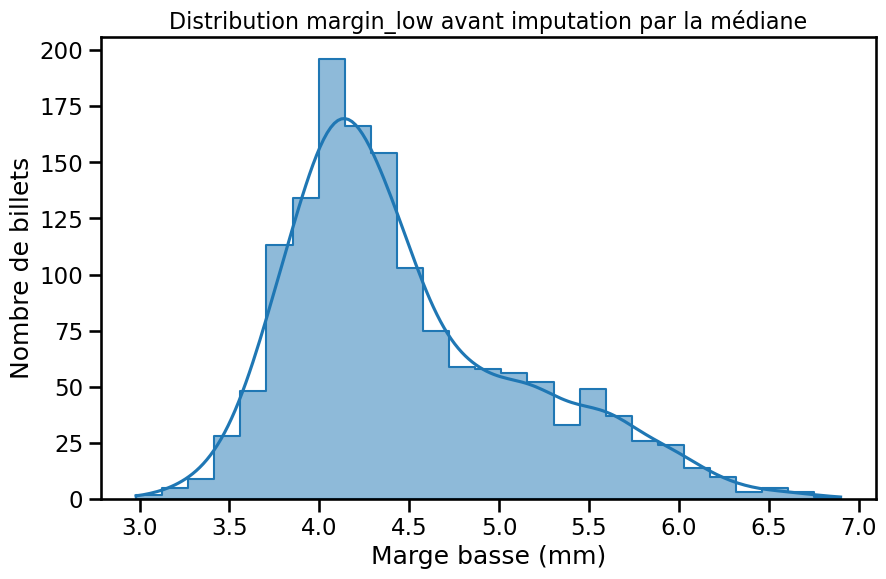

In [98]:
# 1. Configuration du style
plt.figure(figsize=(10, 6))
sns.set_context("talk")

# 2. Création de l'histogramme avec courbe de densité (KDE)
# On sépare par 'is_genuine' pour voir les deux distributions
sns.histplot(data=df_billets, 
             x='margin_low', 
             kde=True, 
             palette='coolwarm', 
             element="step")

# 3. Titres et labels
plt.title('Distribution margin_low avant imputation par la médiane', fontsize=16)
plt.xlabel('Marge basse (mm)')
plt.ylabel('Nombre de billets')

# 4. Enregistrement
plt.savefig('distribution_margin_low.png', dpi=300, bbox_inches='tight')

# 5. Affichage
plt.show()

## Remplacement des valeurs manquantes de la colonne margin_low par la médiane

In [100]:
from sklearn.impute import MissingIndicator, KNNImputer,SimpleImputer
imputer_median = SimpleImputer(strategy='median')
df_billets['margin_low_impute'] = imputer_median.fit_transform(df_billets[['margin_low']])

df_billets.isnull().sum()

is_genuine            0
diagonal              0
height_left           0
height_right          0
margin_low           37
margin_up             0
length                0
margin_low_impute     0
dtype: int64

In [101]:
from sklearn.impute import MissingIndicator, KNNImputer,SimpleImputer
imputer_median = SimpleImputer(strategy='median')
df_billets['margin_low'] = imputer_median.fit_transform(df_billets[['margin_low_impute']])

df_billets.isnull().sum()

is_genuine           0
diagonal             0
height_left          0
height_right         0
margin_low           0
margin_up            0
length               0
margin_low_impute    0
dtype: int64

In [102]:
df_billets = df_billets.drop(columns=['margin_low_impute'])


In [103]:
# Sauvegarde du fichier nettoyé
df_billets.to_csv("billets_nettoyes.csv", index=False)

/var/folders/px/vxsbq6f172sbrm6n__kccm1h0000gp/T/ipykernel_894/4259985865.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_billets,


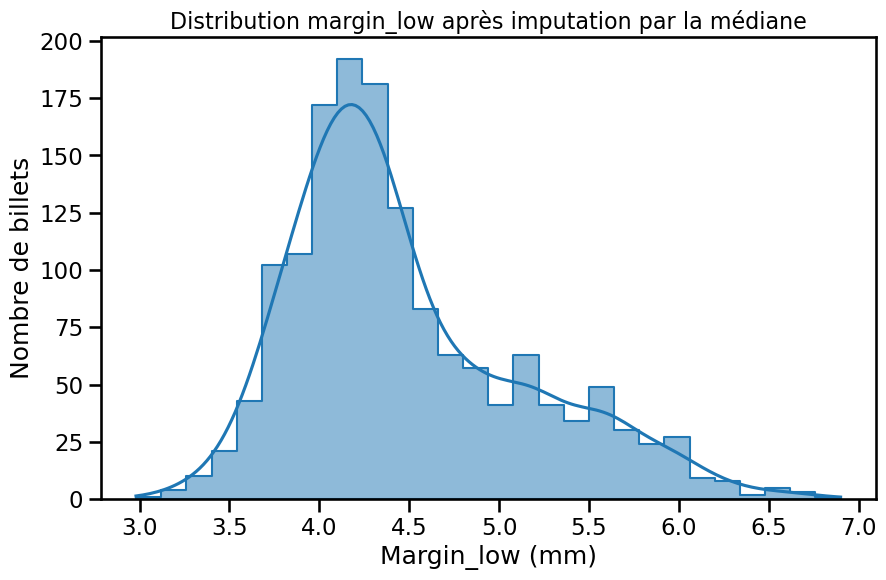

In [104]:
# 1. Configuration du style
plt.figure(figsize=(10, 6))
sns.set_context("talk")

# 2. Création de l'histogramme avec courbe de densité (KDE)
# On sépare par 'is_genuine' pour voir les deux distributions
sns.histplot(data=df_billets, 
             x='margin_low',  
             kde=True, 
             palette='coolwarm', 
             element="step")

# 3. Titres et labels
plt.title('Distribution margin_low après imputation par la médiane', fontsize=16)
plt.xlabel('Margin_low (mm)')
plt.ylabel('Nombre de billets')

# 4. Enregistrement
plt.savefig('distribution_margin_loww.png', dpi=300, bbox_inches='tight')

# 5. Affichage
plt.show()

In [106]:
df_billets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1500 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [107]:
df_billets.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.481627,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.656137,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.030000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.860000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


# Prétraitement

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# 1. On définit X (les caractéristiques) et y (ce qu'on veut prédire)
X = df_billets.drop('is_genuine', axis=1) # On prend tout sauf la réponse
y = df_billets['is_genuine']              # On ne prend que la réponse


# 2. Séparation des données en ensemble d'apprentissage (80%) et Test (20%)
        # Utilisation de l'argument 'stratify' pour garder les proportions 1000/500
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,      # 20% de 1500 = 300 billets au total
    random_state=42, 
    stratify=y           
)

# Vérification des comptes
print("Répartition dans l'ensemble de TEST :")
print(y_test.value_counts())

# 3. Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données d'entraînement :", X_train_scaled.shape)
print("Données de test :", X_test_scaled.shape)

Répartition dans l'ensemble de TEST :
is_genuine
True     200
False    100
Name: count, dtype: int64
Données d'entraînement : (1200, 6)
Données de test : (300, 6)


# Modélisation

## Apprentissage supervisée

### Régression logistique classique

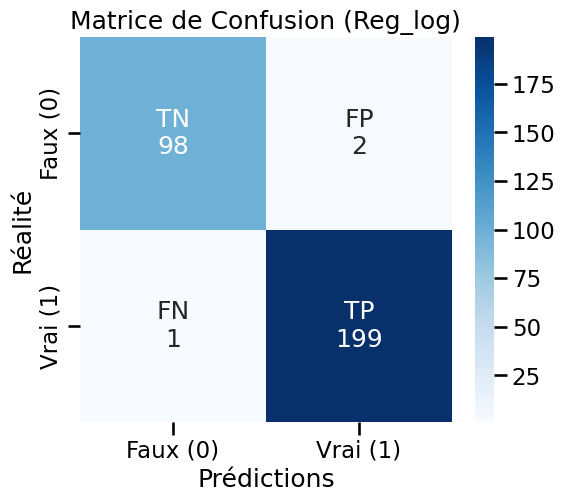


Rapport :
               precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [109]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# 1. Algorithme (Entraînement de la Régression Logistique)
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# 2. Mesure de la performance (Prédiction)
y_pred = log_reg.predict(X_test_scaled) #Par défaut, la fonction predict() de scikit-learn utilise un seuil de 0,5.
                                        #Si la probabilité calculée par la fonction Sigmoïde est supérieure à 0,5, 
                                        #le billet est classé comme "Vrai" (1), sinon il est "Faux" (0).

# 3. Mesure de la performance (Matrice de Confusion)
cf_matrix = confusion_matrix(y_test, y_pred)

# 3.1 Création des labels personnalisés (Abréviations + Valeurs)
    
names = ['TN','FP','FN','TP'] # Ordre dans la matrice : TN, FP, FN, TP
counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(names, counts)]
labels = np.asarray(labels).reshape(2,2)

# 3.2 Affichage
plt.figure(figsize=(6, 5))
sns.heatmap(cf_matrix, annot=labels, fmt="", cmap='Blues',
            xticklabels=['Faux (0)', 'Vrai (1)'], 
            yticklabels=['Faux (0)', 'Vrai (1)'])

plt.title('Matrice de Confusion (Reg_log)')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.show()

print("\nRapport :\n", classification_report(y_test, y_pred))

## Vérification de la performance du modèle

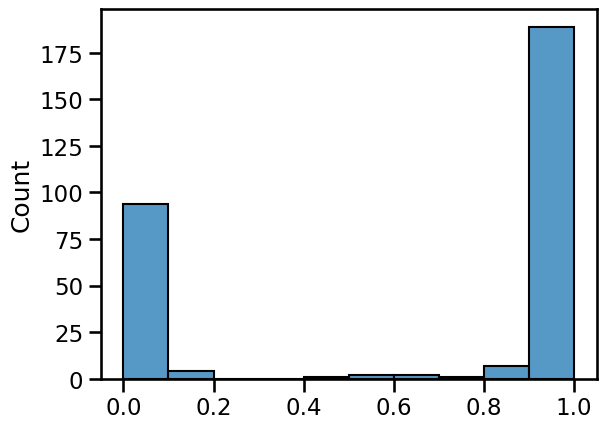

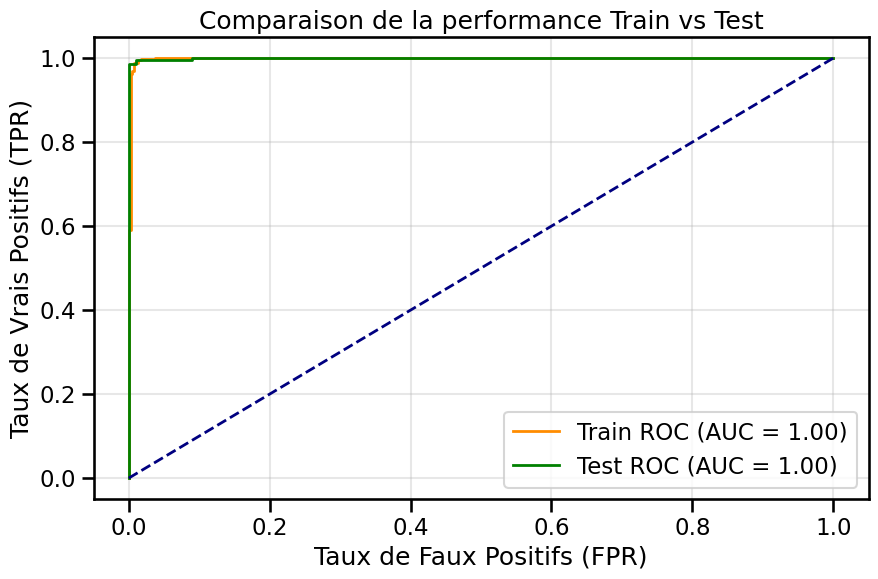

In [110]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Calcul des Probabilités
y_train_probs = log_reg.predict_proba(X_train_scaled)[:, 1]
y_test_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

sns.histplot(y_test_probs)
# 2. Calcul des métriques ROC(Receiver Operating Characteristic)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_probs)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_test_probs)
roc_auc_test = auc(fpr_test, tpr_test)

# 3. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label=f'Train ROC (AUC = {roc_auc_train:.2f})')
plt.plot(fpr_test, tpr_test, color='green', lw=2, label=f'Test ROC (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Comparaison de la performance Train vs Test')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Interprétation des scores AUC
AUC = 1.00 (Train) : Le modèle a appris à séparer parfaitement les vrais billets des faux sur les données qu'il a déjà vues.

AUC = 1.00 (Test) : C'est le point le plus important. Le modèle maintient cette perfection sur de nouvelles données. Cela signifie qu'il n'y a aucun surapprentissage (overfitting).

In [111]:
# Extraction des coefficients liés aux 6 variables
variables = X_train.columns
df_coef = pd.DataFrame({
    'Variable': variables,
    'Coefficient': log_reg.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("Influence des dimensions sur la probabilité 'VRAI' :")
print(df_coef)


Influence des dimensions sur la probabilité 'VRAI' :
       Variable  Coefficient
5        length     3.730087
0      diagonal     0.206033
1   height_left    -0.315453
2  height_right    -0.714255
4     margin_up    -1.628652
3    margin_low    -2.679411


Coefficient très positif :  length     3.7, Plus cette mesure est grande, plus le billet est considéré comme vrai.

Coefficient très négatif :margin_low    -2.67, Plus cette mesure est grande, plus le billet est considéré comme faux.

### KNN (K-Nearest Neighbors)

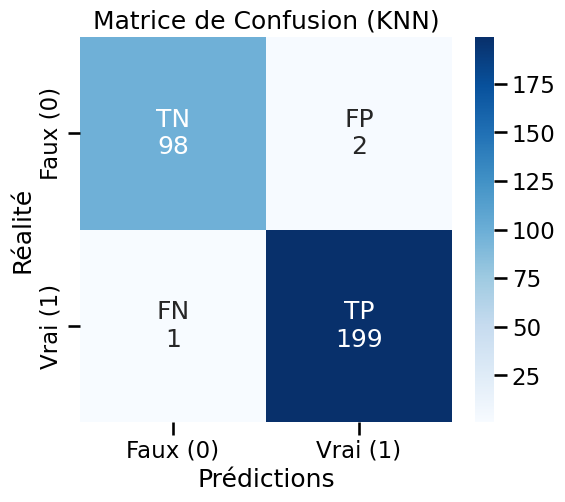


Rapport (KNN) :
               precision    recall  f1-score   support

       False       0.99      0.98      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



In [112]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Création du modèle
knn = KNeighborsClassifier(n_neighbors=10)

# 2. Entraînement
knn.fit(X_train_scaled, y_train)

# 3. Prédiction
y_pred_knn = knn.predict(X_test_scaled)

# 4. Évaluation
# 4.1. Calcul de la matrice
cf_matrix = confusion_matrix(y_test, y_pred_knn)

# 4.2 Création des labels personnalisés (Abréviations + Valeurs)
    
names = ['TN','FP','FN','TP'] # Ordre dans la matrice : TN, FP, FN, TP
counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(names, counts)]
labels = np.asarray(labels).reshape(2,2)

# 4.3 Affichage
plt.figure(figsize=(6, 5))
sns.heatmap(cf_matrix, annot=labels, fmt="", cmap='Blues',
            xticklabels=['Faux (0)', 'Vrai (1)'], 
            yticklabels=['Faux (0)', 'Vrai (1)'])

plt.title('Matrice de Confusion (KNN)')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.show()

print("\nRapport (KNN) :\n", classification_report(y_test, y_pred_knn))

### Random forest

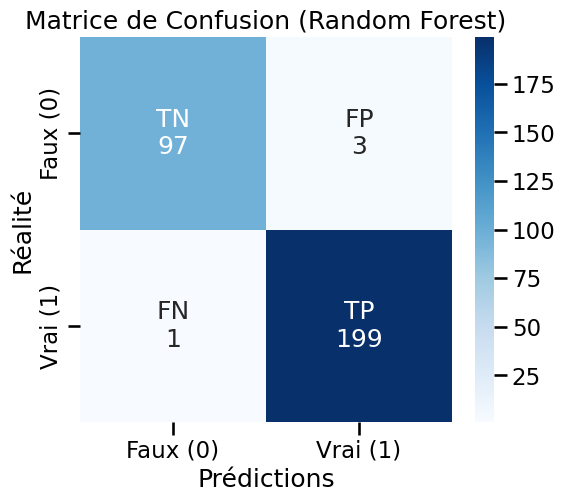


Rapport (Random Forest) :
               precision    recall  f1-score   support

       False       0.99      0.97      0.98       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.98      0.98       300
weighted avg       0.99      0.99      0.99       300



In [113]:
from sklearn.ensemble import RandomForestClassifier

# 1. Création du modèle
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Entraînement
rf.fit(X_train_scaled, y_train)

# 3. Prédiction
y_pred_rf = rf.predict(X_test_scaled)

# 4. Évaluation
# 4.1. Calcul de la matrice
cf_matrix = confusion_matrix(y_test, y_pred_rf)

# 4.2 Création des labels personnalisés (Abréviations + Valeurs)
    
names = ['TN','FP','FN','TP'] # Ordre dans la matrice : TN, FP, FN, TP
counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(names, counts)]
labels = np.asarray(labels).reshape(2,2)

# 4.3 Affichage
plt.figure(figsize=(6, 5))
sns.heatmap(cf_matrix, annot=labels, fmt="", cmap='Blues',
            xticklabels=['Faux (0)', 'Vrai (1)'], 
            yticklabels=['Faux (0)', 'Vrai (1)'])

plt.title('Matrice de Confusion (Random Forest)')
plt.xlabel('Prédictions')
plt.ylabel('Réalité')
plt.show()

print("\nRapport (Random Forest) :\n", classification_report(y_test, y_pred_rf))

## Apprentissage non supervisée

### k-means

In [128]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df_billets.drop('is_genuine', axis=1) if 'is_genuine' in df_billets.columns else df_billets

results = []
for k in range(2, 6): # On teste de 2 à 5 clusters
    model = KMeans(n_init=10, n_clusters=k, random_state=42).fit(X)
    inertia = model.inertia_
    sil_score = silhouette_score(X, model.labels_)
    results.append({'K': k, 'Inertia': round(inertia, 2), 'Silhouette': round(sil_score, 4)})

# Création du tableau récapitulatif
df_recap = pd.DataFrame(results)

# Identification automatique du Best K (basé sur le score de silhouette max)
best_k = df_recap.loc[df_recap['Silhouette'].idxmax(), 'K']

print(f"--- Analyse des Clusters ---")
print(df_recap)
print(f"\nLe meilleur nombre de clusters (Best K) est : {best_k}")

--- Analyse des Clusters ---
   K  Inertia  Silhouette
0  2   976.55      0.5133
1  3   868.08      0.3893
2  4   778.70      0.1723
3  5   713.38      0.1716

Le meilleur nombre de clusters (Best K) est : 2


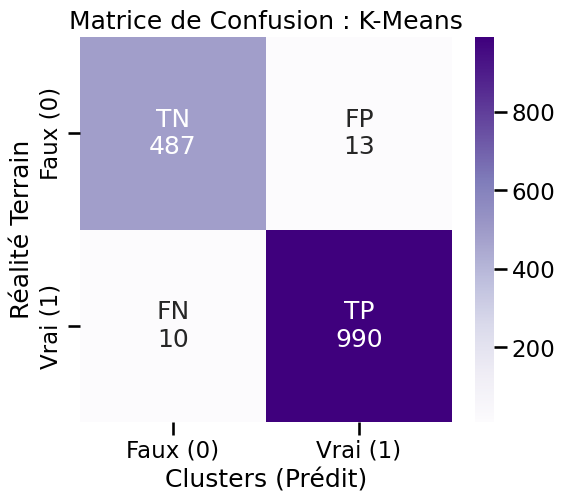


Rapport (K-Means) :
               precision    recall  f1-score   support

       False       0.98      0.97      0.98       500
        True       0.99      0.99      0.99      1000

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500

Coefficient de Silhouette : 0.341
Accuracy sur les 1500 billets : 98.47%


In [127]:
from sklearn.metrics import silhouette_score, accuracy_score

# 1. Standardisation de la totalité des données
X_scaled_all = scaler.fit_transform(X) # X contient les 1500 billets

# 2. Entraînement du K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_scaled_all)
clusters = kmeans.labels_

# 3. Évaluation de la forme 
score_sil = silhouette_score(X_scaled_all, clusters)

# 4. Redressement pour l'accuracy (comparaison avec la réalité du dataset complet)
if y[clusters == 0].mean() > 0.5:
    y_pred_km = [True if c == 0 else False for c in clusters]
else:
    y_pred_km = [True if c == 1 else False for c in clusters]

acc_kmeans = accuracy_score(y, y_pred_km)

# 5. Évaluation

# 5.1. Calcul de la matrice
cf_matrix_km = confusion_matrix(y, y_pred_km)

# 5.2. Création des labels personnalisés (Abréviations + Valeurs)
names = ['TN','FP','FN','TP']
counts = ["{0:0.0f}".format(value) for value in cf_matrix_km.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(names, counts)]
labels = np.asarray(labels).reshape(2,2)

# 5.3. Affichage de la Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cf_matrix_km, annot=labels, fmt="", cmap='Purples',
            xticklabels=['Faux (0)', 'Vrai (1)'], 
            yticklabels=['Faux (0)', 'Vrai (1)'])

plt.title(f'Matrice de Confusion : K-Means')
plt.xlabel('Clusters (Prédit)')
plt.ylabel('Réalité Terrain')
plt.show()

print("\nRapport (K-Means) :\n", classification_report(y, y_pred_km))
print(f"Coefficient de Silhouette : {score_sil:.3f}")
print(f"Accuracy sur les 1500 billets : {acc_kmeans:.2%}")

### Caractérisation des Groupes (Le "Profilage")

In [117]:
# On crée un DataFrame temporaire avec les données originales et les clusters
df_analyse = pd.DataFrame(X, columns=['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length'])
df_analyse['Cluster_Label'] = y_pred_km # On utilise tes labels "VRAI/FAUX" redressés

# On calcule la moyenne de chaque dimension pour les VRAIS et les FAUX
profils = df_analyse.groupby('Cluster_Label').mean()
print("--- CARACTÉRISTIQUES MOYENNES PAR GROUPE ---")
print(profils)

--- CARACTÉRISTIQUES MOYENNES PAR GROUPE ---
                 diagonal  height_left  height_right  margin_low  margin_up  \
Cluster_Label                                                                 
False          171.899256   104.199759    104.151590    5.205795   3.351871   
True           171.987767   103.945184    103.805703    4.122792   3.052173   

                   length  
Cluster_Label              
False          111.631630  
True           113.197238  


En comparant les moyennes, on identifie immédiatement les variables discriminantes (celles qui changent beaucoup).

La Variable Clé : margin_low C'est la différence la plus flagrante. Les faux billets ont une marge inférieure moyenne de 5.21 mm, contre 4.12 mm pour les vrais. Une marge basse trop large est un signe fort de contrefaçon.

Le second indicateur : length Les vrais billets sont plus longs (113.20 mm) que les faux (111.63 mm). Il y a presque 1.5 mm de différence, ce qui est énorme en précision fiduciaire.

### Visualisation de la séparation (Projection)

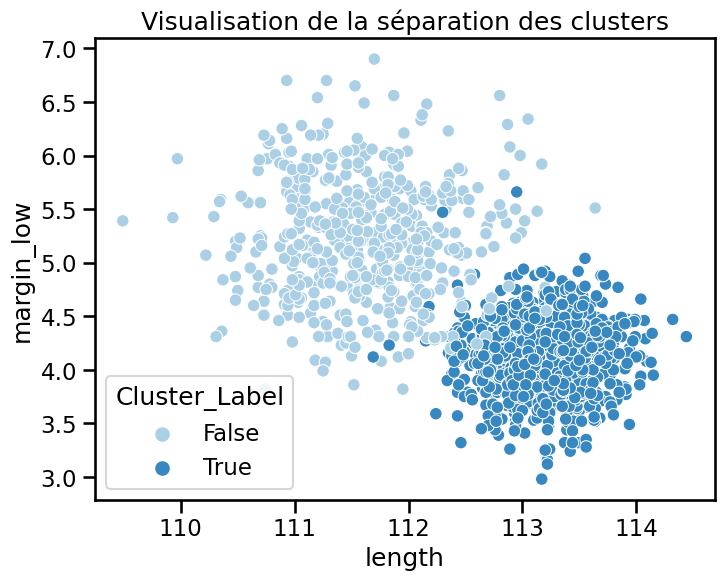

In [118]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_analyse, x='length', y='margin_low', hue='Cluster_Label', palette='Blues')
plt.title('Visualisation de la séparation des clusters')
plt.show()

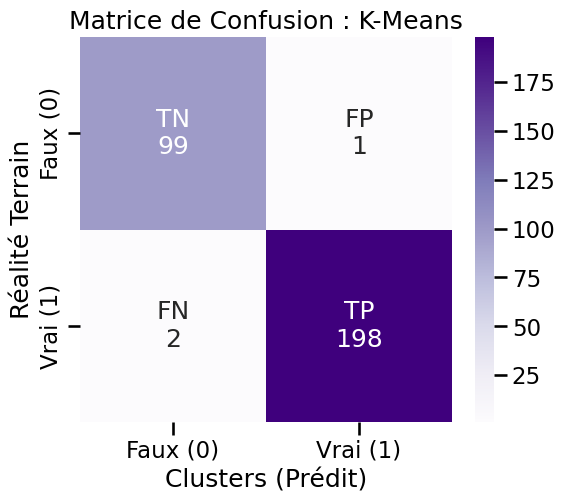


Rapport (K-Means) :
               precision    recall  f1-score   support

       False       0.98      0.99      0.99       100
        True       0.99      0.99      0.99       200

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Coefficient de Silhouette : 0.329


In [119]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score


# 2. Entraînement du K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_test_scaled)
clusters = kmeans.labels_

# 3. Évaluation de la forme 
score_sil = silhouette_score(X_test_scaled, clusters)

# 4. Redressement pour l'accuracy 
if y_test[clusters == 0].mean() > 0.5:
    y_pred_km = [True if c == 0 else False for c in clusters]
else:
    y_pred_km = [True if c == 1 else False for c in clusters]

acc_kmeans = accuracy_score(y_test, y_pred_km)

# 5. Évaluation

# 5.1. Calcul de la matrice de confusion
cf_matrix_km = confusion_matrix(y_test, y_pred_km)

# 5.2. Création des labels personnalisés (Abréviations + Valeurs)
names = ['TN','FP','FN','TP']
counts = ["{0:0.0f}".format(value) for value in cf_matrix_km.flatten()]
labels = [f"{v1}\n{v2}" for v1, v2 in zip(names, counts)]
labels = np.asarray(labels).reshape(2,2)

# 5.3. Affichage de la Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cf_matrix_km, annot=labels, fmt="", cmap='Purples',
            xticklabels=['Faux (0)', 'Vrai (1)'], 
            yticklabels=['Faux (0)', 'Vrai (1)'])

plt.title(f'Matrice de Confusion : K-Means')
plt.xlabel('Clusters (Prédit)')
plt.ylabel('Réalité Terrain')
plt.show()

print("\nRapport (K-Means) :\n", classification_report(y_test, y_pred_km))
print(f"Coefficient de Silhouette : {score_sil:.3f}")


In [120]:
from sklearn.metrics import accuracy_score

# Calcul des scores sur l'ensemble de test uniquement
acc_rf = accuracy_score(y_test, rf.predict(X_test_scaled))
acc_lr = accuracy_score(y_test, log_reg.predict(X_test_scaled))
acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
#acc_kmeans = accuracy_score(y, y_pred_km)
acc_kmeans = accuracy_score(y_test, y_pred_km)

supervise_scores = pd.DataFrame({
    'Modèle': ['Random Forest', 'Régression Logistique', 'KNN', 'K-Means (Unsupervised)'],
    'Accuracy (Test Set)': [acc_rf, acc_lr, acc_knn, acc_kmeans]
}).sort_values(by='Accuracy (Test Set)', ascending=False)

print(supervise_scores)

                   Modèle  Accuracy (Test Set)
1   Régression Logistique             0.990000
2                     KNN             0.990000
3  K-Means (Unsupervised)             0.990000
0           Random Forest             0.986667


### Performance des modèles

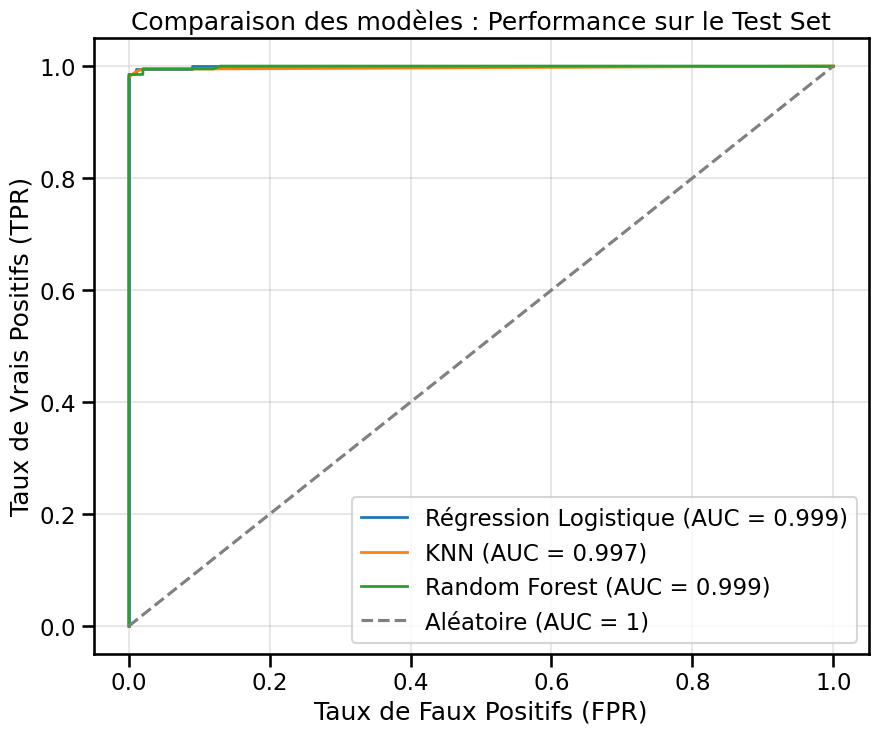

In [121]:

models = {
    'Régression Logistique': (log_reg, X_test_scaled),
    'KNN': (knn, X_test_scaled),
    'Random Forest': (rf, X_test_scaled)
}

plt.figure(figsize=(10, 8))

for name, (model, X_data) in models.items():
    # Récupération des probas pour la classe positive (Faux billets)
    probs = model.predict_proba(X_data)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Ligne de base (Hasard)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Aléatoire (AUC = 1)')

plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (TPR)')
plt.title('Comparaison des modèles : Performance sur le Test Set')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Régression Logistique (AUC = 0.999) : Performance quasi parfaite. C'est un modèle linéaire qui excelle quand la séparation entre les classes est nette.

Random Forest (AUC = 0.999) : Également au sommet. Sa capacité à capter des relations non-linéaires complexes confirme la robustesse des données.

KNN (AUC = 0.997) : Très performant, bien que légèrement en retrait par rapport aux deux autres.

### Mise en production avec le modèle 'Régression logistique'

In [122]:
def detecteur_faux_billets(billets_production):
   
    # 1. Chargement des nouveaux billets
    df_prod = pd.read_csv("billets_production.csv")
    
    # On garde une copie pour le résultat final
    resultat = df_prod.copy()
    
    # 2. Préparation (On sélectionne nos 6 variables géométriques)
    # Rappel:Le fichier de Marie n'a pas la colonne 'is_genuine'
    X_prod = df_prod[variables]
    
    # 3. Standardisation (IMPORTANT : on utilise le scaler déjà entraîné)
    X_prod_scaled = scaler.transform(X_prod)
    
    # 4. Prédiction avec le modèle Régression logistique
    predictions = log_reg.predict(X_prod_scaled)
    probabilites = log_reg.predict_proba(X_prod_scaled)[:, 1] # Probabilité d'être un vrai
    
    # 5. Formatage du résultat
    resultat['Prediction'] = predictions
    resultat['Probabilité_Vrai'] = probabilites.round(4)
    resultat['Verdict'] = resultat['Prediction'].map({True: 'VRAI BILLET', False: 'FAUX BILLET'})
    
    return resultat[['id', 'Verdict', 'Probabilité_Vrai']]

In [123]:
# Appel de la fonction sur le fichier de production
resultats_finaux = detecteur_faux_billets("billets_production.csv")

# Affichage des premières lignes pour vérifier
print("Aperçu des résultats de production :")
print(resultats_finaux.head())

# Compter le nombre de vrais et de faux
stats = resultats_finaux['Verdict'].value_counts()
print("\nRésumé de l'analyse :")
print(f"- Nombre de billets authentiques : {stats['VRAI BILLET']}")
print(f"- Nombre de billets contrefaits : {stats['FAUX BILLET']}")

Aperçu des résultats de production :
    id      Verdict  Probabilité_Vrai
0  A_1  FAUX BILLET            0.0009
1  A_2  FAUX BILLET            0.0002
2  A_3  FAUX BILLET            0.0003
3  A_4  VRAI BILLET            0.9794
4  A_5  VRAI BILLET            0.9998

Résumé de l'analyse :
- Nombre de billets authentiques : 2
- Nombre de billets contrefaits : 3


### Mise en production avec tous les modèles

In [124]:
def test_tous_les_modeles(billets_production):
    df_prod = pd.read_csv("billets_production.csv")
    variables = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
    X_prod_scaled = scaler.transform(df_prod[variables])
    
    # Initialisation du tableau
    comparatif = pd.DataFrame({'id': df_prod['id']})

    # 1. Régression Logistique
    comparatif['Reg_Logistique'] = log_reg.predict(X_prod_scaled)

    # 2. KNN
    comparatif['KNN'] = knn.predict(X_prod_scaled)
    
    # 3. Random Forest
    comparatif['Random_Forest'] = rf.predict(X_prod_scaled)
    
    # 4. K-Means
    clusters_prod = kmeans.predict(X_prod_scaled)
    
    train_clusters = kmeans.predict(X_train_scaled) 
    
    # On identifie quel cluster (0 ou 1) correspond aux "VRAI"
    if np.mean(y_train[train_clusters == 0]) > 0.5:
        cluster_vrai = 0
    else:
        cluster_vrai = 1
        
    comparatif['KMeans'] = [True if c == cluster_vrai else False for c in clusters_prod]

    # Remplacer les True/False par "VRAI" / "FAUX"
    for col in ['Random_Forest', 'Reg_Logistique', 'KNN', 'KMeans']:
        comparatif[col] = comparatif[col].map({True: 'VRAI', False: 'FAUX', 1: 'VRAI', 0: 'FAUX'})
        
    return comparatif


In [125]:
# 1. Appeler la fonction
resultats = test_tous_les_modeles('billets_production.csv')

# 2. Sauvegarder la variable
resultats.to_csv("resultats_final_comparaison.csv", index=False)

print("Fichier de résultats enregistré !")

Fichier de résultats enregistré !


In [126]:
import joblib

# 1. Sauvegarde du Scaler (indispensable pour tous les modèles)
joblib.dump(scaler, 'scaler_billets.joblib')

# 2. Sauvegarde des modèles supervisés
joblib.dump(rf, 'modele_rf.joblib')       # Random Forest
joblib.dump(log_reg, 'modele_logreg.joblib')     # Régression Logistique
joblib.dump(knn, 'modele_knn.joblib')             # KNN

# 3. Sauvegarde du modèle non-supervisé
joblib.dump(kmeans, 'modele_kmeans.joblib')       # K-Means

print("Tous les modèles ont été sauvegardés avec succès !")

Tous les modèles ont été sauvegardés avec succès !
